implementation for laplacian eigen options on the four rooms environment. 

In [21]:
#Imports

import numpy as np
import torch
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm 
import math

this cell holds all the hyperparameters used throughout.

In [22]:
HYPERPARAMS = {
    "gamma": 0.9,                  # Discount rate (used for both PI and SMDP)
    "alpha": 0.1,                  # Learning rate for SMDP Q-learning
    "epsilon_start": 1.0,          # Initial exploration rate
    "epsilon_min": 0.10,           # Minimum exploration rate
    "num_episodes": 2000,           # Total training episodes
    "max_steps": 200,              # Max steps per episode
    "num_options_to_use": 64       # 4 primitive + 64 options = 68 total actions
}

now we define our four rooms environment. 

In [23]:
class FourRoomsEnv(gym.Env):
    def __init__(self, bottleneck_rewards=False):
        super().__init__()

        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards

        self.action_space = spaces.Discrete(4)

        self.observation_space = spaces.Box(
            low=0.0,
            high=float(self.grid_size),
            shape=(6,),
            dtype=np.float32,
        )

        self.goal_state = (0, 10)
        self.walls = set()

        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))

        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]

        for doorway in self.doorway_list:
            self.walls.remove(doorway)

        self.valid_states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) not in self.walls:
                    self.valid_states.append((r, c))

        self.state_to_idx = {
            state: idx for idx, state in enumerate(self.valid_states)
        }
        self.idx_to_state = {
            idx: state for state, idx in self.state_to_idx.items()
        }
        self.num_states = len(self.valid_states)

        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.visited_doorways.clear()

        idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]

        return self._get_obs(), {}

    def step(self, action):
        if isinstance(action, torch.Tensor):
            action = action.item()
        else:
            action = int(action)

        self.current_step += 1
        r, c = self.current_state

        if action == 0:
            r -= 1
        elif action == 1:
            c += 1
        elif action == 2:
            r += 1
        elif action == 3:
            c -= 1

        if (
            0 <= r < self.grid_size
            and 0 <= c < self.grid_size
            and (r, c) not in self.walls
        ):
            self.current_state = (r, c)

        terminated = self.current_state == self.goal_state
        truncated = self.current_step >= self.max_steps

        reward = 10.0 if terminated else 0.0

        if (
            self.bottleneck_rewards
            and self.current_state in self.doorway_list
            and self.current_state not in self.visited_doorways
        ):
            reward += 0.5
            self.visited_doorways.add(self.current_state)

        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        r, c = self.current_state
        obs = [float(r), float(c)]

        for doorway in self.doorway_list:
            obs.append(
                1.0 if doorway in self.visited_doorways else 0.0
            )

        return np.array(obs, dtype=np.float32)

    def get_state_idx(self):
        return self.state_to_idx[self.current_state]

we'll build the adjacency matrix for the environment. 

In [24]:
def build_adjacency_matrix(env):
    num_states = env.num_states
    adjacency = np.zeros((num_states, num_states), dtype=np.float32)

    for state, state_idx in env.state_to_idx.items():
        r, c = state

        for action in range(env.action_space.n):
            next_r, next_c = r, c

            if action == 0:
                next_r -= 1
            elif action == 1:
                next_c += 1
            elif action == 2:
                next_r += 1
            elif action == 3:
                next_c -= 1

            if (
                0 <= next_r < env.grid_size
                and 0 <= next_c < env.grid_size
                and (next_r, next_c) not in env.walls
            ):
                next_state = (next_r, next_c)

                if next_state in env.state_to_idx:
                    next_idx = env.state_to_idx[next_state]

                    if state_idx != next_idx:
                        adjacency[state_idx, next_idx] = 1.0

    return adjacency

we'll build the degree matrix for the adjacency matrix. 

In [25]:
def build_degree_matrix(A):
    degrees = np.sum(A, axis=1)
    return np.diag(degrees)

we'll compute the normalized laplacian. 

In [26]:
def build_normalized_laplacian(A, D):
    degrees = np.diag(D)

    # Avoid division by zero for isolated nodes.
    d_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-8)

    D_inv_sqrt = np.diag(d_inv_sqrt)

    return D_inv_sqrt @ (D - A) @ D_inv_sqrt

here we'll store all visualization related variables. 

In [27]:
#settings for all plots.
VIZ_CONFIG = {
    "fig_size": (15, 5),
    "cmap_matrices": "viridis",  
    "cmap_heatmaps": "coolwarm",
    "font_size": 12,
    "title_color": "#1f2833"
}

#styling
plt.rcParams.update({
    "font.size": VIZ_CONFIG["font_size"],
    "axes.titlesize": 14,
    "axes.titlecolor": VIZ_CONFIG["title_color"],
    "axes.titleweight": "bold"
})

lets visualize the created matrices 

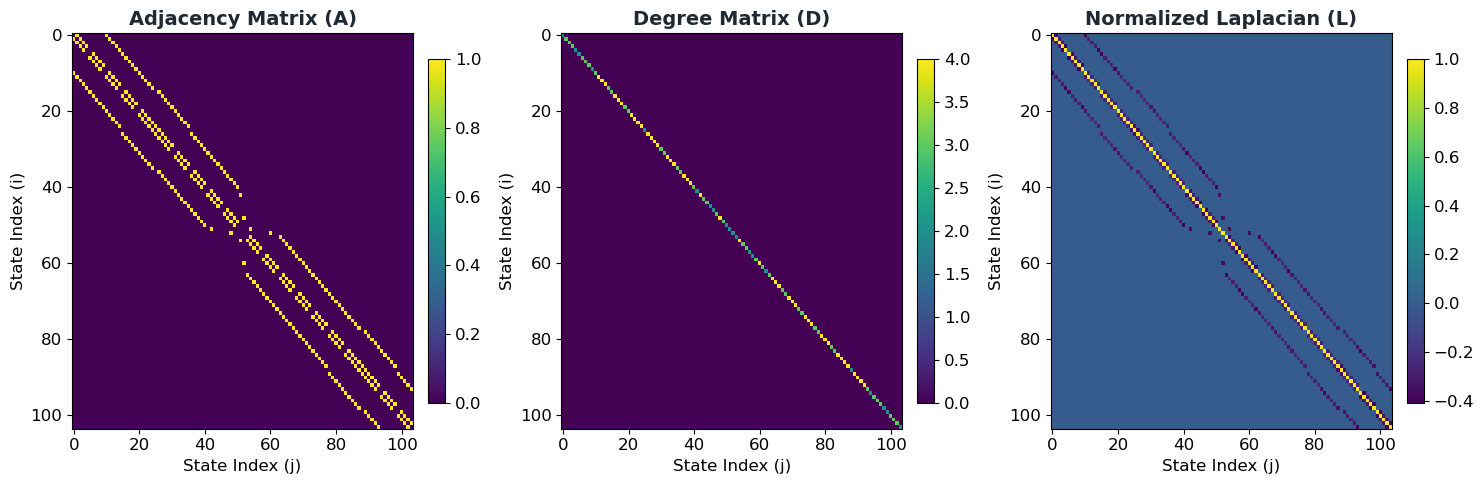

In [28]:
def plot_graph_matrices(env):
    adjacency = build_adjacency_matrix(env)
    degree = build_degree_matrix(adjacency)
    laplacian = build_normalized_laplacian(adjacency, degree)

    fig, axes = plt.subplots(1, 3, figsize=VIZ_CONFIG["fig_size"])

    im0 = axes[0].imshow(
        adjacency,
        cmap=VIZ_CONFIG["cmap_matrices"],
        aspect="auto",
    )
    axes[0].set_title("Adjacency Matrix (A)")
    axes[0].set_xlabel("State Index (j)")
    axes[0].set_ylabel("State Index (i)")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        degree,
        cmap=VIZ_CONFIG["cmap_matrices"],
        aspect="auto",
    )
    axes[1].set_title("Degree Matrix (D)")
    axes[1].set_xlabel("State Index (j)")
    axes[1].set_ylabel("State Index (i)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(
        laplacian,
        cmap=VIZ_CONFIG["cmap_matrices"],
        aspect="auto",
    )
    axes[2].set_title("Normalized Laplacian (L)")
    axes[2].set_xlabel("State Index (j)")
    axes[2].set_ylabel("State Index (i)")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


env = FourRoomsEnv()
plot_graph_matrices(env)

now we do eigendecomposition on the normalized laplacian and get our protovalue functions (PVFs)

In [29]:
def compute_pvfs(L, discard_first=True):
    eigenvalues, eigenvectors = np.linalg.eigh(L)

    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # The first eigenvector is the trivial constant solution.
    if discard_first:
        eigenvalues = eigenvalues[1:]
        eigenvectors = eigenvectors[:, 1:]

    return eigenvalues, eigenvectors

now we'll refine our eigenpurposes, which are just the intrinsic reward functions

In [30]:
def get_intrinsic_reward(eigenpurpose_vector, current_state_idx, next_state_idx):
    return eigenpurpose_vector[next_state_idx] - eigenpurpose_vector[current_state_idx]

lets visualize our eigenpurposes. 

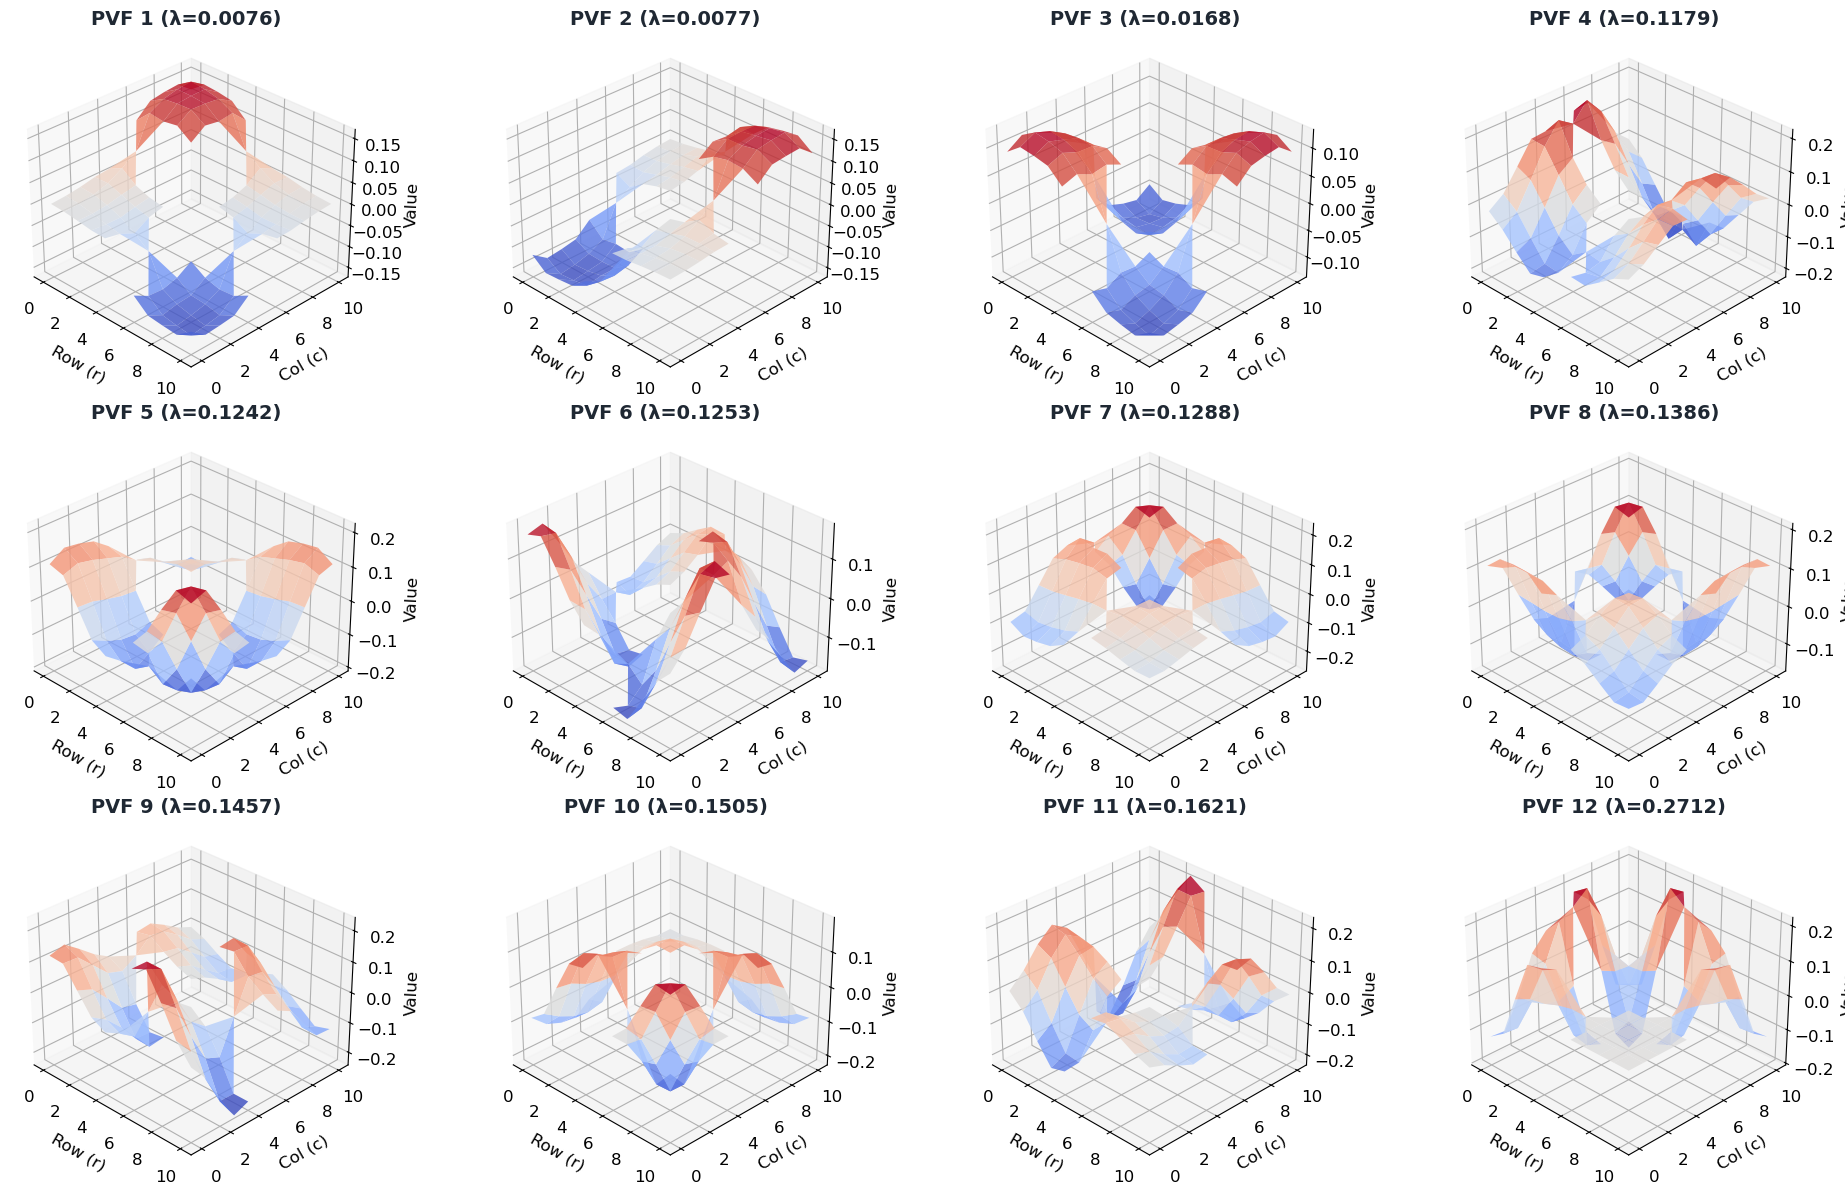

In [31]:
def reshape_pvf_to_2d(env, pvf):
    grid = np.full((env.grid_size, env.grid_size), np.nan)

    for state, state_idx in env.state_to_idx.items():
        r, c = state
        grid[r, c] = pvf[state_idx]

    return grid


def plot_pvfs_3d(env, eigenvalues, eigenvectors, num_to_plot=4):
    n_cols = int(np.ceil(np.sqrt(num_to_plot)))
    n_rows = int(np.ceil(num_to_plot / n_cols))

    fig = plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    X, Y = np.meshgrid(
        np.arange(env.grid_size),
        np.arange(env.grid_size),
    )

    for i in range(num_to_plot):
        pvf = eigenvectors[:, i]
        Z = reshape_pvf_to_2d(env, pvf)

        ax = fig.add_subplot(
            n_rows,
            n_cols,
            i + 1,
            projection="3d",
        )

        ax.plot_surface(
            X,
            Y,
            Z,
            cmap=VIZ_CONFIG["cmap_heatmaps"],
            edgecolor="none",
            alpha=0.8,
        )

        ax.set_title(
            f"PVF {i + 1} (λ={eigenvalues[i]:.4f})"
        )
        ax.set_xlabel("Row (r)")
        ax.set_ylabel("Col (c)")
        ax.set_zlabel("Value")

        ax.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.show()


env = FourRoomsEnv()

A = build_adjacency_matrix(env)
D = build_degree_matrix(A)
L = build_normalized_laplacian(A, D)

eigenvalues, eigenvectors = compute_pvfs(
    L,
    discard_first=True,
)

plot_pvfs_3d(
    env,
    eigenvalues,
    eigenvectors,
    num_to_plot=12,
)

now we'll use policy iteration to train our eigenbehaviours (basically just options). first we define the transition dynamics

In [32]:
def get_deterministic_next_state(env, state_idx, action):
    state = env.idx_to_state[state_idx]
    r, c = state

    next_r, next_c = r, c

    if action == 0:
        next_r -= 1
    elif action == 1:
        next_c += 1
    elif action == 2:
        next_r += 1
    elif action == 3:
        next_c -= 1

    if (
        0 <= next_r < env.grid_size
        and 0 <= next_c < env.grid_size
        and (next_r, next_c) not in env.walls
    ):
        next_state = (next_r, next_c)
    else:
        next_state = state

    return env.state_to_idx[next_state]

now, policy iteration.

In [33]:
def policy_iteration_eigenoption(
    env,
    eigenpurpose_vector,
    gamma=0.9,
    max_iters=1000,
    tol=1e-6,
):
    num_states = env.num_states
    num_actions = 4

    policy = np.random.randint(
        0,
        num_actions,
        size=num_states,
    )
    V = np.zeros(num_states)

    for _ in range(max_iters):
        for _ in range(1000):
            delta = 0.0
            new_V = np.zeros(num_states)

            for state_idx in range(num_states):
                action = policy[state_idx]

                if action == 4:
                    new_V[state_idx] = 0.0
                else:
                    next_state_idx = get_deterministic_next_state(
                        env,
                        state_idx,
                        action,
                    )

                    reward = (
                        eigenpurpose_vector[next_state_idx]
                        - eigenpurpose_vector[state_idx]
                    )

                    new_V[state_idx] = (
                        reward
                        + gamma * V[next_state_idx]
                    )

                delta = max(
                    delta,
                    abs(new_V[state_idx] - V[state_idx]),
                )

            V = new_V

            if delta < tol:
                break

        policy_stable = True
        Q = np.zeros((num_states, num_actions + 1))

        for state_idx in range(num_states):
            old_action = policy[state_idx]

            for action in range(num_actions):
                next_state_idx = get_deterministic_next_state(
                    env,
                    state_idx,
                    action,
                )

                reward = (
                    eigenpurpose_vector[next_state_idx]
                    - eigenpurpose_vector[state_idx]
                )

                Q[state_idx, action] = (
                    reward
                    + gamma * V[next_state_idx]
                )

            Q[state_idx, 4] = 0.0

            best_action = np.argmax(Q[state_idx])
            policy[state_idx] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    initiation_set = []
    termination_set = []

    for state_idx in range(num_states):
        max_primitive_q = np.max(Q[state_idx, :4])

        if max_primitive_q > 0:
            initiation_set.append(state_idx)
            policy[state_idx] = np.argmax(Q[state_idx, :4])
        else:
            policy[state_idx] = 4
            termination_set.append(state_idx)

    return {
        "policy": policy,
        "Q": Q,
        "initiation_set": initiation_set,
        "termination_set": termination_set,
    }

training loop to build the option bank

In [34]:
def build_option_bank(
    env,
    eigenvalues,
    eigenvectors,
    gamma,
):
    options_bank = []
    num_eigenvectors = eigenvectors.shape[1]

    for i in range(num_eigenvectors):
        pvf = eigenvectors[:, i]

        print(
            f"Training Option "
            f"{len(options_bank) + 1}/{num_eigenvectors * 2} "
            f"(Eigenvector {i + 1} - Uphill)"
        )

        option_positive = policy_iteration_eigenoption(
            env,
            pvf,
            gamma=gamma,
        )

        options_bank.append({
            "id": len(options_bank),
            "eigenvalue": eigenvalues[i],
            "direction": "positive",
            "policy": option_positive["policy"],
            "initiation_set": option_positive["initiation_set"],
            "termination_set": option_positive["termination_set"],
        })

        print(
            f"Training Option "
            f"{len(options_bank) + 1}/{num_eigenvectors * 2} "
            f"(Eigenvector {i + 1} - Downhill)"
        )

        option_negative = policy_iteration_eigenoption(
            env,
            -pvf,
            gamma=gamma,
        )

        options_bank.append({
            "id": len(options_bank),
            "eigenvalue": eigenvalues[i],
            "direction": "negative",
            "policy": option_negative["policy"],
            "initiation_set": option_negative["initiation_set"],
            "termination_set": option_negative["termination_set"],
        })

    print("Option Bank construction complete!")
    return options_bank


options_bank = build_option_bank(
    env,
    eigenvalues,
    eigenvectors,
    gamma=HYPERPARAMS["gamma"],
)

print(f"Total options stored in bank: {len(options_bank)}")

Training Option 1/206 (Eigenvector 1 - Uphill)
Training Option 2/206 (Eigenvector 1 - Downhill)
Training Option 3/206 (Eigenvector 2 - Uphill)
Training Option 4/206 (Eigenvector 2 - Downhill)
Training Option 5/206 (Eigenvector 3 - Uphill)
Training Option 6/206 (Eigenvector 3 - Downhill)
Training Option 7/206 (Eigenvector 4 - Uphill)
Training Option 8/206 (Eigenvector 4 - Downhill)
Training Option 9/206 (Eigenvector 5 - Uphill)
Training Option 10/206 (Eigenvector 5 - Downhill)
Training Option 11/206 (Eigenvector 6 - Uphill)
Training Option 12/206 (Eigenvector 6 - Downhill)
Training Option 13/206 (Eigenvector 7 - Uphill)
Training Option 14/206 (Eigenvector 7 - Downhill)
Training Option 15/206 (Eigenvector 8 - Uphill)
Training Option 16/206 (Eigenvector 8 - Downhill)
Training Option 17/206 (Eigenvector 9 - Uphill)
Training Option 18/206 (Eigenvector 9 - Downhill)
Training Option 19/206 (Eigenvector 10 - Uphill)
Training Option 20/206 (Eigenvector 10 - Downhill)
Training Option 21/206 (Eig

visualizing policies of learned eigenbehaviours

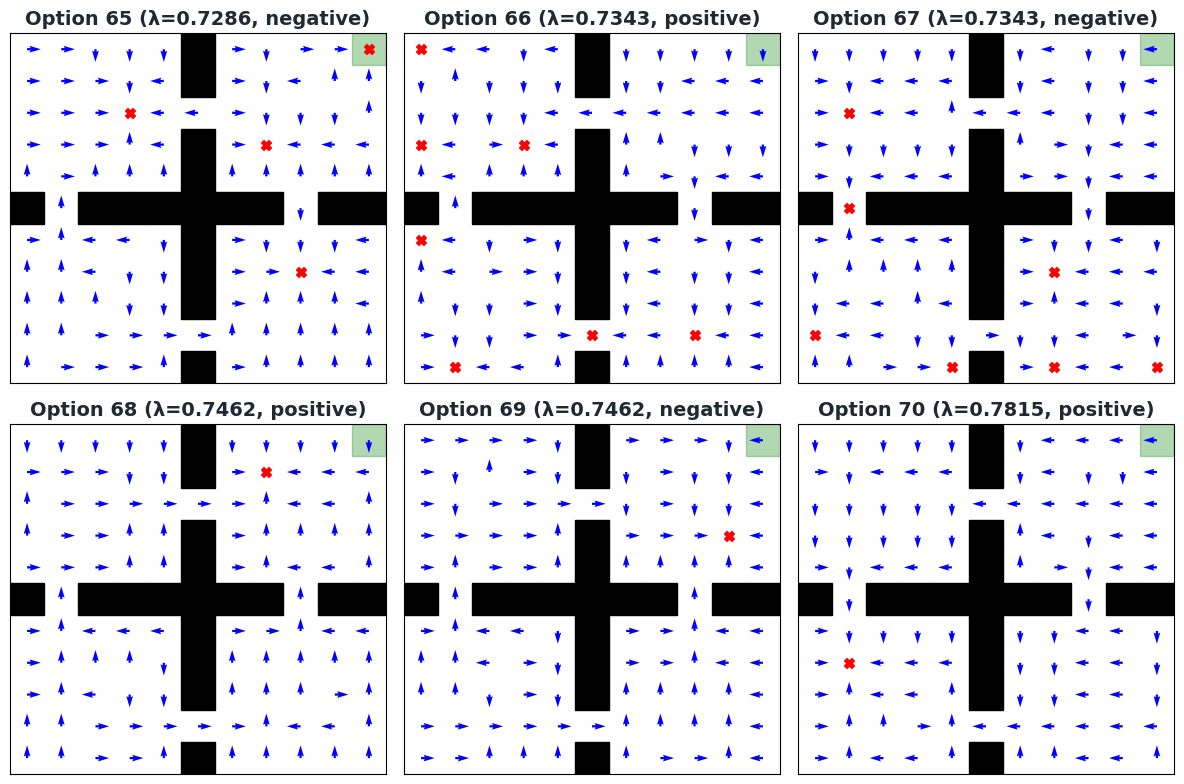

In [35]:
def plot_eigenoption_policies(
    env,
    options_list,
    n_cols=3,
):
    num_options = len(options_list)
    n_rows = int(np.ceil(num_options / n_cols))

    fig_width = 4 * n_cols
    fig_height = 4 * n_rows

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_width, fig_height),
    )

    if num_options == 1:
        axes = np.array([axes])

    axes = axes.flatten()

    for i, option_data in enumerate(options_list):
        ax = axes[i]
        policy = option_data["policy"]

        for r in range(env.grid_size):
            for c in range(env.grid_size):
                if (r, c) in env.walls:
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, env.grid_size - 1 - r - 0.5),
                            1,
                            1,
                            color="black",
                        )
                    )
                elif (r, c) == env.goal_state:
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, env.grid_size - 1 - r - 0.5),
                            1,
                            1,
                            color="green",
                            alpha=0.3,
                        )
                    )

        X, Y, U, V = [], [], [], []

        for state, state_idx in env.state_to_idx.items():
            r, c = state

            x = c
            y = env.grid_size - 1 - r

            action = policy[state_idx]

            if action == 4:
                ax.scatter(
                    x,
                    y,
                    color="red",
                    marker="X",
                    s=50,
                    zorder=5,
                )
            else:
                X.append(x)
                Y.append(y)

                if action == 0:
                    U.append(0)
                    V.append(0.4)
                elif action == 1:
                    U.append(0.4)
                    V.append(0)
                elif action == 2:
                    U.append(0)
                    V.append(-0.4)
                elif action == 3:
                    U.append(-0.4)
                    V.append(0)

        ax.quiver(
            X,
            Y,
            U,
            V,
            angles="xy",
            scale_units="xy",
            scale=1,
            color="blue",
        )

        ax.set_xlim(-0.5, env.grid_size - 0.5)
        ax.set_ylim(-0.5, env.grid_size - 0.5)
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(
            f"Option {option_data['id']} "
            f"(λ={option_data['eigenvalue']:.4f}, "
            f"{option_data['direction']})",
            color=VIZ_CONFIG["title_color"],
            fontweight="bold",
        )

    for ax in axes[num_options:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


options_to_plot = options_bank[65:71]

plot_eigenoption_policies(
    env,
    options_to_plot,
    n_cols=3,
)

we'll prepare the options for training 

In [36]:
def prepare_smdp_options(options_bank, num_options):

    #sort by eigenvalue
    sorted_options = sorted(options_bank, key=lambda x: x['eigenvalue'])
    
    selected_options = sorted_options[:num_options]
    
    print(f"Selected {len(selected_options)} options out of {len(options_bank)}.")
    print(f"Eigenvalue range: {selected_options[0]['eigenvalue']:.4f} to {selected_options[-1]['eigenvalue']:.4f}")
    
    return selected_options

smdp_options = prepare_smdp_options(options_bank, HYPERPARAMS["num_options_to_use"])

Selected 64 options out of 206.
Eigenvalue range: 0.0076 to 0.7170


we'll train the agent in the actual env using smdp-q learning

In [37]:
def smdp_q_learning(env, options, hyperparams):
    num_states = env.num_states
    num_primitive = 4
    num_options = len(options)
    total_actions = num_primitive + num_options  # 4 + 64 = 68
    
    #q-table
    Q_table = np.zeros((num_states, total_actions))
    
    epsilon = hyperparams["epsilon_start"]
    epsilon_min = hyperparams["epsilon_min"]
    epsilon_decay = hyperparams["epsilon_start"] / (hyperparams["num_episodes"] / 2)
    
    alpha = hyperparams["alpha"]
    gamma = hyperparams["gamma"]
    
    episode_rewards = []
    episode_steps = []
    
    for episode in tqdm(range(hyperparams["num_episodes"]), desc="Training SMDP Agent"):
        obs, _ = env.reset()
        state_idx = env.get_state_idx()
        
        total_reward = 0
        step = 0
        
        while step < hyperparams["max_steps"]:
            #e-greedy action selection
            if np.random.rand() < epsilon:
                action_idx = np.random.randint(0, total_actions)
            else:
                action_idx = np.argmax(Q_table[state_idx, :])
                
            if action_idx < num_primitive:
                #primitive actions
                next_obs, reward, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()
                
                #1 step q learning
                target = reward + (0 if terminated else gamma * np.max(Q_table[next_state_idx, :]))
                Q_table[state_idx, action_idx] += alpha * (target - Q_table[state_idx, action_idx])
                
                state_idx = next_state_idx
                total_reward += reward
                step += 1
                
                if terminated or truncated:
                    break
            else:
                #options
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                option_policy = option['policy']
                start_state_idx = state_idx 
                
                k = 0
                option_reward = 0.0
                
                while True:
                    #checking if option terminates
                    if option_policy[state_idx] == 4:
                        break
                    
                    primitive_action = option_policy[state_idx]
                    next_obs, reward, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()
                
                    option_reward += (gamma ** k) * reward
                    k += 1
                    
                    state_idx = next_state_idx
                    total_reward += reward
                    step += 1
                    
                    if terminated or truncated:
                        break
                    if step >= hyperparams["max_steps"]:
                        break
                
                #q learning update
                bootstrapped_value = 0.0
                if not (terminated or truncated):
                    bootstrapped_value = np.max(Q_table[state_idx, :])
                    
                target = option_reward + (gamma ** k) * bootstrapped_value
                
                
                Q_table[start_state_idx, action_idx] += alpha * (target - Q_table[start_state_idx, action_idx])
                
                if terminated or truncated:
                    break
                    
        #epsilon decay
        epsilon = max(epsilon_min, epsilon - epsilon_decay)
        episode_rewards.append(total_reward)
        episode_steps.append(step)
        
    return Q_table, episode_rewards, episode_steps

#training
train_env = FourRoomsEnv()

print("Starting SMDP Q-Learning Training...")
master_Q_table, smdp_rewards, smdp_steps = smdp_q_learning(train_env, smdp_options, HYPERPARAMS)
print("Training Complete!")

Starting SMDP Q-Learning Training...


Training SMDP Agent: 100%|██████████| 2000/2000 [00:00<00:00, 8681.27it/s]

Training Complete!


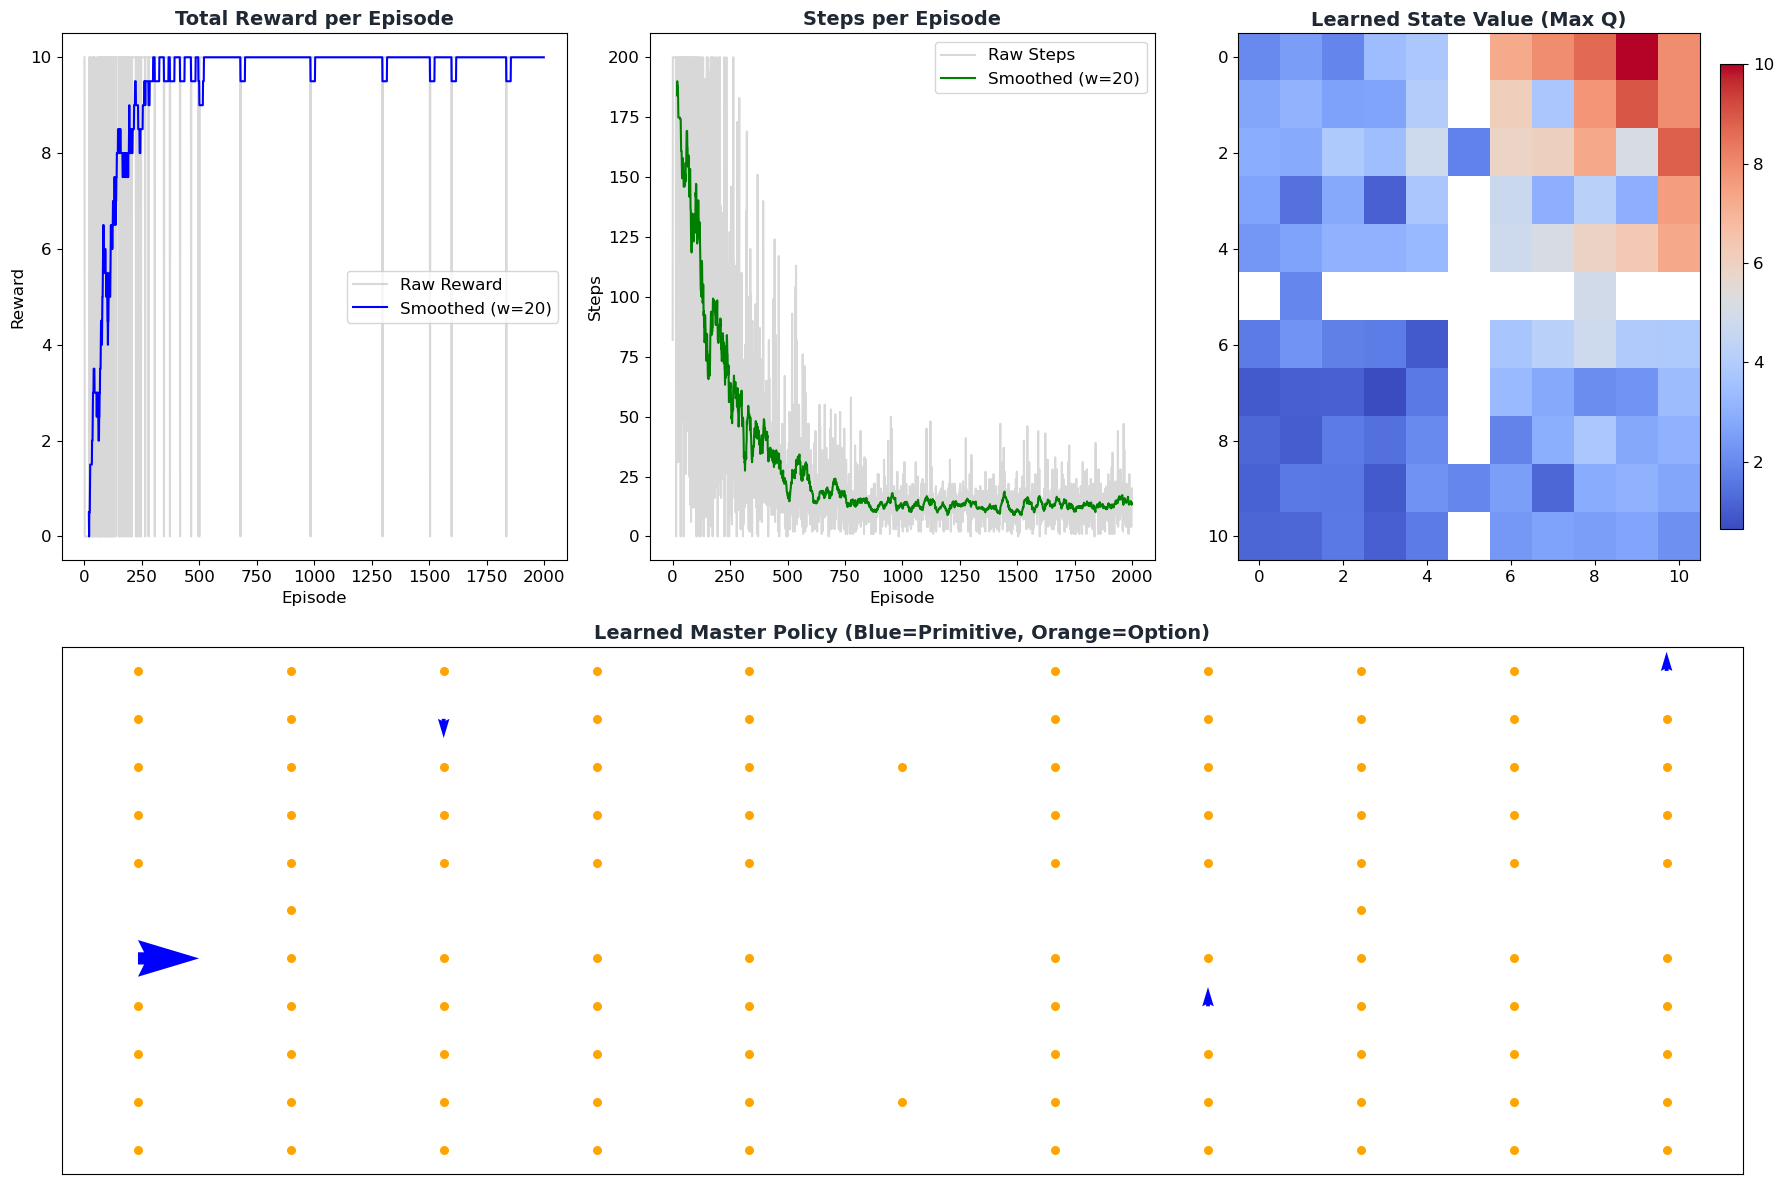

In [38]:
# Cell 19: Robust Visualizations

def plot_smdp_results(env, rewards, steps, Q_table, options, window=20):

    smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
    smoothed_steps = np.convolve(steps, np.ones(window)/window, mode='valid')

    V = np.max(Q_table, axis=1)
    policy = np.argmax(Q_table, axis=1)

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rewards, alpha=0.3, color='gray', label='Raw Reward')
    ax1.plot(np.arange(window-1, len(rewards)), smoothed_rewards, color='blue', label=f'Smoothed (w={window})')
    ax1.set_title("Total Reward per Episode", color=VIZ_CONFIG["title_color"])
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Reward")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(steps, alpha=0.3, color='gray', label='Raw Steps')
    ax2.plot(np.arange(window-1, len(steps)), smoothed_steps, color='green', label=f'Smoothed (w={window})')
    ax2.set_title("Steps per Episode", color=VIZ_CONFIG["title_color"])
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Steps")
    ax2.legend()

    ax3 = fig.add_subplot(gs[0, 2])
    grid_V = np.full((env.grid_size, env.grid_size), np.nan)

    for state, idx in env.state_to_idx.items():
        r, c = state
        grid_V[r, c] = V[idx]

    im = ax3.imshow(grid_V, cmap=VIZ_CONFIG["cmap_heatmaps"], aspect='auto')
    ax3.set_title("Learned State Value (Max Q)", color=VIZ_CONFIG["title_color"])
    fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

    #master policy
    ax4 = fig.add_subplot(gs[1, :])
    X, Y, U, V_vec = [], [], [], []

    for state, idx in env.state_to_idx.items():
        r, c = state
        x, y = c, env.grid_size - 1 - r
        action = policy[idx]

        if action < 4:
            X.append(x)
            Y.append(y)

            if action == 0:
                U.append(0)
                V_vec.append(0.4)      
            elif action == 1:
                U.append(0.4)
                V_vec.append(0)        
            elif action == 2:
                U.append(0)
                V_vec.append(-0.4)     
            elif action == 3:
                U.append(-0.4)
                V_vec.append(0)        
        else:
            # Plot options as orange dots
            ax4.scatter(x, y, color='orange', s=30, zorder=5)

    ax4.quiver(
        X, Y, U, V_vec,
        angles='xy',
        scale_units='xy',
        scale=1,
        color='blue'
    )

    ax4.set_title(
        "Learned Master Policy (Blue=Primitive, Orange=Option)",
        color=VIZ_CONFIG["title_color"]
    )

    ax4.set_xlim(-0.5, env.grid_size - 0.5)
    ax4.set_ylim(-0.5, env.grid_size - 0.5)
    ax4.set_xticks([])
    ax4.set_yticks([])

    plt.tight_layout()
    plt.show()


#dashboard
plot_smdp_results(
    train_env,
    smdp_rewards,
    smdp_steps,
    master_Q_table,
    smdp_options
)

to visualize individual option policies.

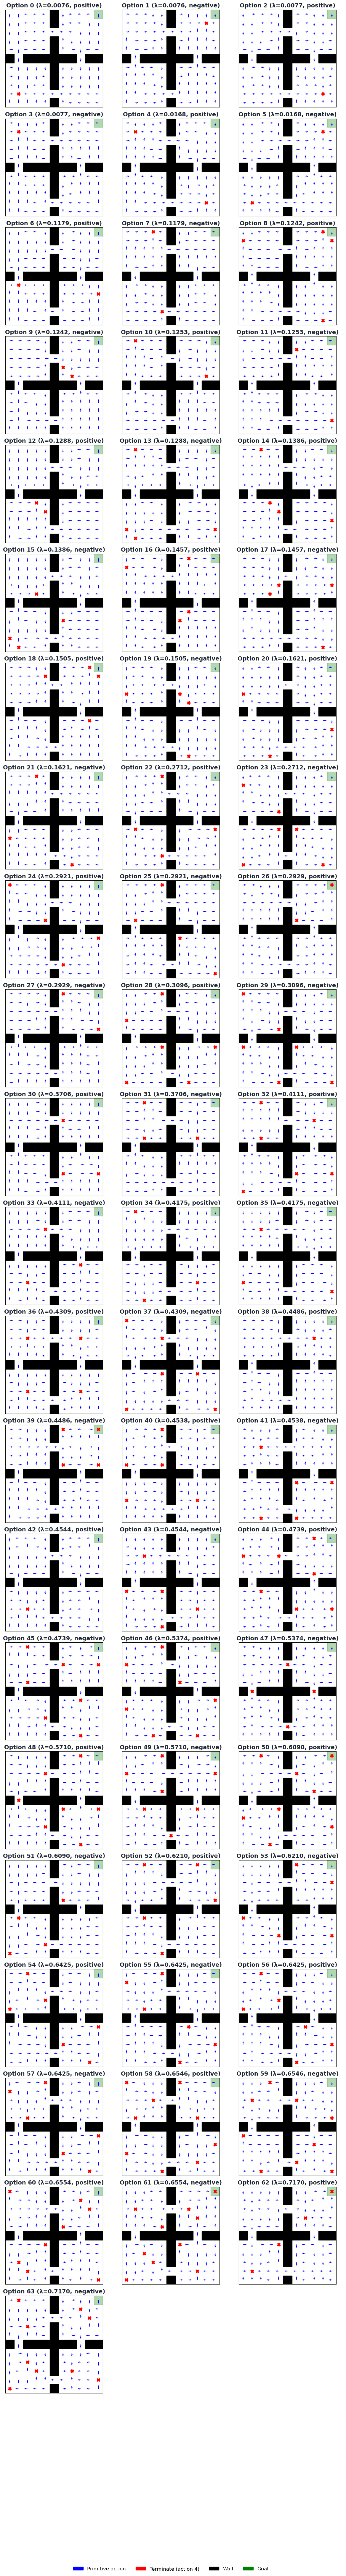

In [39]:
def _draw_eigenoption_on_ax(ax, env, option_data, arrow_color="blue", term_color="red"):
    policy = option_data["policy"]

    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if (r, c) in env.walls:
                ax.add_patch(
                    plt.Rectangle(
                        (c - 0.5, env.grid_size - 1 - r - 0.5),
                        1,
                        1,
                        color="black",
                    )
                )
            elif (r, c) == env.goal_state:
                ax.add_patch(
                    plt.Rectangle(
                        (c - 0.5, env.grid_size - 1 - r - 0.5),
                        1,
                        1,
                        color="green",
                        alpha=0.3,
                    )
                )

    X, Y, U, V = [], [], [], []
    arrow_len = 0.4
    
    action_to_uv = {
        0: (0.0, +arrow_len),  # Up
        1: (+arrow_len, 0.0),  # Right
        2: (0.0, -arrow_len),  # Down
        3: (-arrow_len, 0.0),  # Left
    }

    for state, state_idx in env.state_to_idx.items():
        r, c = state
        x = c
        y = env.grid_size - 1 - r

        action = policy[state_idx]

        if action == 4:
            ax.scatter(
                x,
                y,
                color=term_color,
                marker="X",
                s=60,
                zorder=5,
            )
        else:
            du, dv = action_to_uv[action]
            X.append(x)
            Y.append(y)
            U.append(du)
            V.append(dv)

    if X:
        ax.quiver(
            X,
            Y,
            U,
            V,
            angles="xy",
            scale_units="xy",
            scale=1,
            color=arrow_color,
            width=0.005,
        )

    ax.set_xlim(-0.5, env.grid_size - 0.5)
    ax.set_ylim(-0.5, env.grid_size - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        f"Option {option_data['id']} "
        f"(λ={option_data['eigenvalue']:.4f}, "
        f"{option_data['direction']})",
        color=VIZ_CONFIG["title_color"],
        fontweight="bold",
    )

#to plot a single option
def plot_single_eigenoption(env, options_bank, option_number, figsize=(7, 7)):
    option_data = next((opt for opt in options_bank if opt["id"] == option_number), None)
    if option_data is None:
        raise ValueError(f"Option with id={option_number} not found.")

    fig, ax = plt.subplots(figsize=figsize)
    _draw_eigenoption_on_ax(ax, env, option_data)

    arrow_patch = mpatches.Patch(color="blue", label="Primitive action")
    term_patch = mpatches.Patch(color="red", label="Terminate (action 4)")
    wall_patch = mpatches.Patch(color="black", label="Wall")
    goal_patch = mpatches.Patch(color="green", label="Goal")
    ax.legend(
        handles=[arrow_patch, term_patch, wall_patch, goal_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

#to plot multiple options side by side
def plot_eigenoptions_grid(env, options_bank, option_numbers, n_cols=3):

    opts_to_plot = []
    for num in option_numbers:
        option_data = next((opt for opt in options_bank if opt["id"] == num), None)
        if option_data is None:
            raise ValueError(f"Option with id={num} not found.")
        opts_to_plot.append(option_data)

    num_plots = len(opts_to_plot)
    n_rows = math.ceil(num_plots / n_cols)
    
    fig, axes = plt.subplots(
        n_rows, 
        n_cols, 
        figsize=(4 * n_cols, 4 * n_rows)
    )
    
    if num_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, option_data in enumerate(opts_to_plot):
        _draw_eigenoption_on_ax(axes[i], env, option_data)
    
    for j in range(num_plots, len(axes)):
        axes[j].axis("off")

    #legend
    arrow_patch = mpatches.Patch(color="blue", label="Primitive action")
    term_patch = mpatches.Patch(color="red", label="Terminate (action 4)")
    wall_patch = mpatches.Patch(color="black", label="Wall")
    goal_patch = mpatches.Patch(color="green", label="Goal")
    
    fig.legend(
        handles=[arrow_patch, term_patch, wall_patch, goal_patch],
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    plt.tight_layout()
    # Adjust bottom margin to make room for the legend
    plt.subplots_adjust(bottom=0.08) 
    plt.show()

#for one option
# plot_single_eigenoption(env, options_bank, option_number=3)

#for a range of options.
plot_eigenoptions_grid(env, options_bank, option_numbers=range(64), n_cols=3)

#for passing a custom list 
#plot_eigenoptions_grid(env, options_bank, option_numbers=[0, 10, 20, 30], n_cols=2)